# Data preprocessing

In [ ]:
import pandas as pd
import numpy as np

df_diet = pd.read_csv('digital_diet_mental_health.csv')
df_sleep = pd.read_csv('sleep_mobile_stress_dataset_15000.csv')
df_prod = pd.read_csv('student_productivity_distraction_dataset_20000.csv')
df_health = pd.read_csv('Impact_of_Mobile_Phone_on_Students_Health.csv')

# parsing the productivity data
df_prod['final_grade'] = pd.to_numeric(df_prod['final_grade'], errors='coerce')
df_prod['study_hours_per_day'] = pd.to_numeric(df_prod['study_hours_per_day'], errors='coerce')

# parsing the sleep data
df_sleep['sleep_duration_hours'] = pd.to_numeric(df_sleep['sleep_duration_hours'], errors='coerce')
df_sleep['stress_level'] = pd.to_numeric(df_sleep['stress_level'], errors='coerce')

# parsing the diet data
df_diet['daily_screen_time_hours'] = pd.to_numeric(df_diet['daily_screen_time_hours'], errors='coerce')

# cleaning the datasets by removing rows with missing critical values
df_prod_clean = df_prod.dropna(subset=['final_grade', 'study_hours_per_day'])
df_sleep_clean = df_sleep.dropna(subset=['sleep_duration_hours', 'stress_level'])
df_diet_clean = df_diet.dropna(subset=['daily_screen_time_hours'])

# summarizing the final datasets
print(f"Productivity: {df_prod_clean.shape[0]} entries, {df_prod_clean.shape[1]} features")
print(f"Sleep: {df_sleep_clean.shape[0]} entries, {df_sleep_clean.shape[1]} features")
print(f"Diet: {df_diet_clean.shape[0]} entries, {df_diet_clean.shape[1]} features")

print(df_prod_clean.head())
print(df_sleep_clean.head())
print(df_diet_clean.head())

Productivity: 20000 entries, 18 features
Sleep: 15000 entries, 13 features
Diet: 2000 entries, 25 features
   student_id  age  gender  study_hours_per_day  sleep_hours  \
0           1   23  Female                 4.35         3.63   
1           2   20    Male                 6.14         6.58   
2           3   29  Female                 4.98         3.26   
3           4   27  Female                 3.19         4.58   
4           5   24    Male                 7.67         6.21   

   phone_usage_hours  social_media_hours  youtube_hours  gaming_hours  \
0               3.38                2.73           1.83          5.26   
1               5.48                1.51           3.13          1.73   
2               4.83                3.63           0.18          4.71   
3              10.06                3.95           5.75          2.52   
4               3.02                1.59           5.46          5.65   

   breaks_per_day  coffee_intake_mg  exercise_minutes  assignments_co

# Basic data exploration and summary statistics

F-statistic: 959.6355340197306
p-value: 0.0


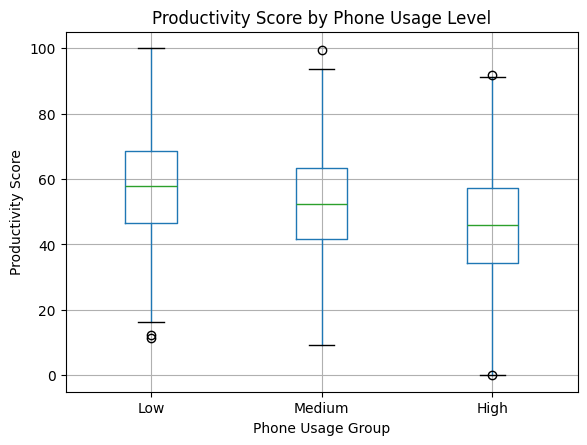

In [ ]:
from scipy.stats import f_oneway
import pandas as pd
import matplotlib.pyplot as plt

# Creating groups for comparison
df_prod['usage_group'] = pd.cut(
    df_prod['phone_usage_hours'],
    bins=[0, 3, 6, 12],
    labels=['Low', 'Medium', 'High']
)

low = df_prod[df_prod['usage_group'] == 'Low']['productivity_score']
medium = df_prod[df_prod['usage_group'] == 'Medium']['productivity_score']
high = df_prod[df_prod['usage_group'] == 'High']['productivity_score']

f_stat, p_value = f_oneway(low, medium, high)

print("F-statistic:", f_stat)
print("p-value:", p_value)

df_prod.boxplot(column='productivity_score', by='usage_group')

plt.title('Productivity Score by Phone Usage Level')
plt.suptitle('')
plt.xlabel('Phone Usage Group')
plt.ylabel('Productivity Score')

plt.show()

**What are the main characteristics of your dataset?**

The dataset analyzes the relationship between phone usage and student productivity. The dataset is organized as a table, where each row represents one person and each column represents a specific type of information, such as how many hours they use their phone or their productivity score.

**How many features and entries are there?**

The dataset contains around 20,000 entries and 19 features that capture both behavioral and performance-related variables.


**1.) Testing if features are correlated**

r value: -0.32665040403164136
p value: 0.0


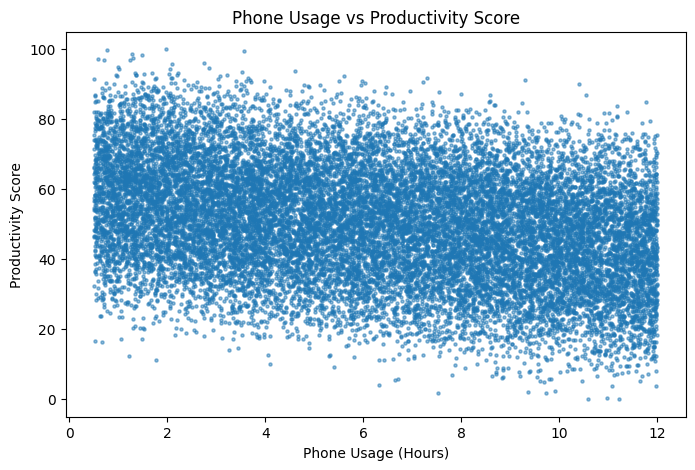

In [ ]:
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

r, p = pearsonr(df_prod_clean['phone_usage_hours'], df_prod_clean['productivity_score'])
print(f"r value: {r}")
print(f"p value: {p}")

plt.figure(figsize=(8, 5))
plt.scatter(df_prod_clean['phone_usage_hours'], df_prod_clean['productivity_score'], alpha=0.5, s=5)
plt.xlabel('Phone Usage (Hours)')
plt.ylabel('Productivity Score')
plt.title('Phone Usage vs Productivity Score')
plt.show()

Picking a significance level of 0.05  
H0: There is no relationship between phone usage hours and productivity score  
HA: There is a relationship between phone usage and productivity score

Since p < 0.05 we reject the null hypothesis and conclude that there is a relationship between phone usage and productivity score. The r value of -0.326 indicates that there is a weak negative correlation between phone usage and productivity.

## 2. Testing Stress Levels against Wellness App Usage

T-statistic: -0.2598
P-value: 7.9505e-01


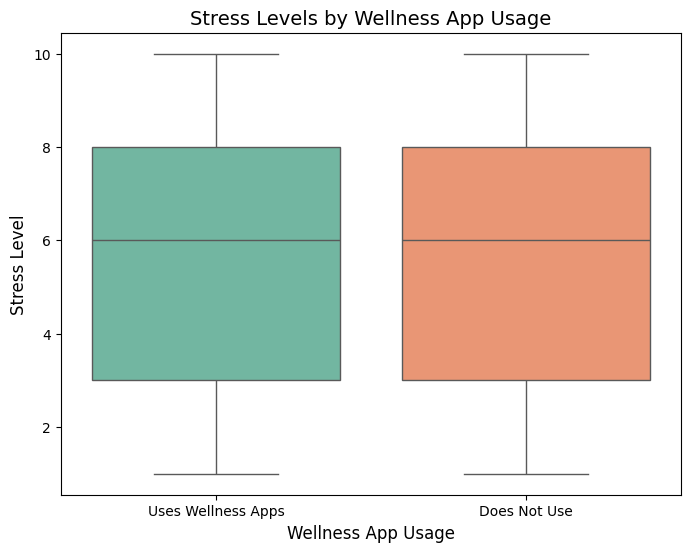

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# 1. Prepare the data
# Filter the diet dataset into two groups based on wellness app usage
no_apps_stress = df_diet_clean[df_diet_clean['uses_wellness_apps'] == 0]['stress_level']
uses_apps_stress = df_diet_clean[df_diet_clean['uses_wellness_apps'] == 1]['stress_level']

# 2. Do a standard Independent Two-Sample T-Test
t_stat, p_val = ttest_ind(no_apps_stress, uses_apps_stress, nan_policy='omit')

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4e}")

# 3. Creating box-plot
plt.figure(figsize=(8, 6))

# Mapping 0 and 1 into strings
plot_data = df_diet_clean.copy()
plot_data['Wellness_App_Status'] = plot_data['uses_wellness_apps'].map({0: 'Does Not Use', 1: 'Uses Wellness Apps'})

# Create the boxplot
sns.boxplot(
    x = 'Wellness_App_Status',
    y = 'stress_level',
    data = plot_data,
    hue='Wellness_App_Status',
    palette = 'Set2'
)

# Add titles and labels
plt.title('Stress Levels by Wellness App Usage', fontsize=14)
plt.xlabel('Wellness App Usage', fontsize=12)
plt.ylabel('Stress Level', fontsize=12)

# Show the plot
plt.show()

Picking a significance level of 0.05
*   H0: There is no difference in mean stress levels between students who use wellness apps and students who do not.
*   HA: There is a difference in mean stress levels between students who use wellness apps and students who do not.

Since p = 0.795 > 0.05, we fail to reject the null hypothesis. There is no statistical evidence to conclude that using wellness apps has a relationship with average stress levels in this dataset. The boxplot plotted supports this, showing nearly identical distributions, medians, and quartiles for both groups.

